In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("/content/02_house_price.csv")

In [ ]:
df.head()

,area_sqft,bedrooms,age_years,distance_city_km,price_lakh
0,849.0,5.0,33.0,17.6,66.5
1,2068.0,4.0,18.0,1.6,120.2
2,1352.0,3.0,30.0,9.6,96.7
3,655.0,3.0,36.0,5.2,51.2
4,1062.0,1.0,32.0,24.0,58.4


In [ ]:
print("Rows:", df.shape[0])

Rows: 1020


In [ ]:
print("Columns:", df.shape[1])

Columns: 5


In [ ]:
print(df.columns.tolist())

['area_sqft', 'bedrooms', 'age_years', 'distance_city_km', 'price_lakh']


In [ ]:
df.shape

(1020, 5)

In [ ]:
df.columns

Index(['area_sqft', 'bedrooms', 'age_years', 'distance_city_km', 'price_lakh'], dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1020 entries, 0 to 1019
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   area_sqft         1010 non-null   float64
 1   bedrooms          1010 non-null   float64
 2   age_years         1010 non-null   float64
 3   distance_city_km  1010 non-null   float64
 4   price_lakh        1020 non-null   float64
dtypes: float64(5)
memory usage: 40.0 KB


In [ ]:
df.describe()

,area_sqft,bedrooms,age_years,distance_city_km,price_lakh
count,1010.000000,1010.000000,1010.000000,1010.000000,1020.000000
mean,1752.415842,3.034653,20.003960,12.768317,101.199118
std,723.614694,1.466436,11.644553,6.931038,33.088497
min,-500.000000,1.000000,0.000000,1.100000,-20.000000
25%,1174.250000,2.000000,10.000000,6.625000,77.275000
50%,1769.000000,3.000000,20.000000,12.600000,102.150000
75%,2388.500000,4.000000,30.000000,18.775000,127.425000
max,2995.000000,10.000000,40.000000,25.000000,177.000000


In [ ]:
print(df.dtypes)

area_sqft           float64
bedrooms            float64
age_years           float64
distance_city_km    float64
price_lakh          float64
dtype: object


In [ ]:
for col in df.columns:
    print(f"\n{col}:")
    print(df[col].unique()[:20])


area_sqft:
[ 849. 2068. 1352.  655. 1062. 1911. 2520. 2560. 1427. 2332. 2178.  694.
 1172. 2491. 2995.  702.  628. 1118. 1569. 1229.]

bedrooms:
[ 5.  4.  3.  1.  2. nan 10.]

age_years:
[33. 18. 30. 36. 32.  4. 35. 27. 14. 10. 22. nan  1.  9. 23. 24. 16. 39.
 11.  5.]

distance_city_km:
[17.6  1.6  9.6  5.2 24.  20.7  1.1  6.2 23.2 21.1 19.8  8.3 12.3 22.7
 20.2 24.9  9.9  2.5 11.2  8.5]

price_lakh:
[ 66.5 120.2  96.7  51.2  58.4 103.1 108.3 154.3  72.  119.1 120.  101.7
  72.6  65.9 127.8 143.1  43.4  45.9  62.8  84.5]


In [ ]:
# missing values

missing_values = df.isnull().sum()

print(missing_values)

area_sqft           10
bedrooms            10
age_years           10
distance_city_km    10
price_lakh           0
dtype: int64


In [ ]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

print(missing_percentage)

area_sqft           0.980392
bedrooms            0.980392
age_years           0.980392
distance_city_km    0.980392
price_lakh          0.000000
dtype: float64


In [ ]:
missing_summary = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing Percentage": (df.isnull().sum() / len(df)) * 100
})

missing_summary

,Missing Values,Missing Percentage
area_sqft,10,0.980392
bedrooms,10,0.980392
age_years,10,0.980392
distance_city_km,10,0.980392
price_lakh,0,0.000000


In [ ]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 20


In [ ]:
# duplicate values

df.duplicated().sum()

np.int64(20)

In [ ]:
# duplicate rows

duplicates = df[df.duplicated()]
print("Duplicate Rows:")
print(duplicates)

Duplicate Rows:
      area_sqft  bedrooms  age_years  distance_city_km  price_lakh
243      1590.0       4.0        9.0              11.9       101.7
247       805.0       3.0       12.0              22.7        44.3
293      1543.0       4.0       14.0              15.8       118.5
401      2965.0       3.0       28.0              23.0       135.6
449      2838.0       1.0       22.0              12.6       152.6
473      2374.0       1.0        2.0              15.7       103.7
477      2906.0       4.0        8.0               3.7       159.6
506       510.0       2.0       15.0               6.9        70.9
527      1896.0       2.0       13.0               3.7       116.4
619      1199.0       5.0       18.0               6.5       107.2
634       690.0       1.0       35.0              14.9        26.6
660      2826.0       5.0       22.0              11.0       176.8
674      1473.0       1.0       24.0              10.5        85.0
714      2754.0       2.0       20.0          

In [ ]:
# Invalid(impossible) values

print(df[df["area_sqft"] < 0])

     area_sqft  bedrooms  age_years  distance_city_km  price_lakh
75      -500.0       3.0       29.0               9.1       158.2
340     -500.0       5.0       28.0              13.0       123.8
537     -500.0       3.0       32.0              25.0        59.5
611     -500.0       5.0       34.0              12.7       101.4
953     -500.0       2.0        9.0               7.5        79.9


In [ ]:
df["bedrooms"].value_counts().sort_index()

,count
bedrooms,
1.0,191
2.0,203
3.0,213
4.0,211
5.0,187
10.0,5


In [ ]:
print(df[df["bedrooms"] < 0])

Empty DataFrame
Columns: [area_sqft, bedrooms, age_years, distance_city_km, price_lakh]
Index: []


In [ ]:
print(df[df["age_years"] < 0])

Empty DataFrame
Columns: [area_sqft, bedrooms, age_years, distance_city_km, price_lakh]
Index: []


In [ ]:
print(df[df["distance_city_km"] < 0])

Empty DataFrame
Columns: [area_sqft, bedrooms, age_years, distance_city_km, price_lakh]
Index: []


In [ ]:
print(df[df["price_lakh"] < 0])

     area_sqft  bedrooms  age_years  distance_city_km  price_lakh
563     2121.0       1.0       11.0              10.4       -20.0
627      811.0       3.0        6.0              19.3       -20.0
687     2136.0       1.0       16.0              13.9       -20.0
790     2644.0       3.0       14.0              14.6       -20.0
853      504.0       3.0       21.0               3.4       -20.0


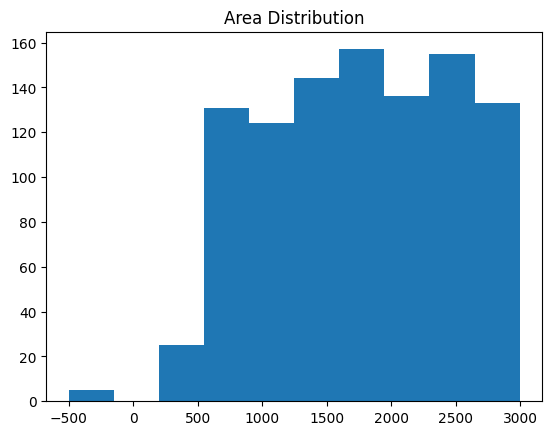

In [ ]:
plt.hist(df["area_sqft"].dropna(), bins=10)

plt.title("Area Distribution")
plt.show()

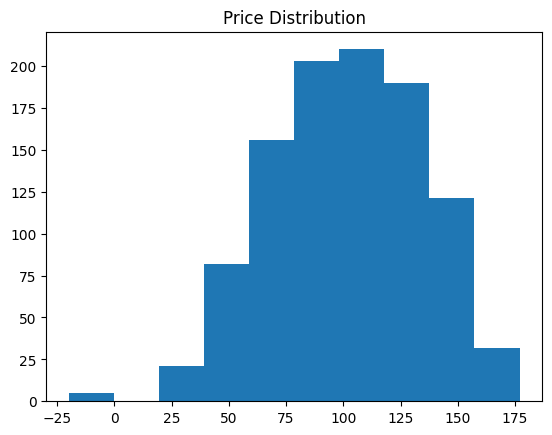

In [ ]:
plt.hist(df["price_lakh"].dropna(), bins=10)

plt.title("Price Distribution")
plt.show()

In [ ]:
# Outliers

Q1 = df["price_lakh"].quantile(0.25)
Q3 = df["price_lakh"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Q1: 77.275
Q3: 127.42500000000001
IQR: 50.150000000000006
Lower Bound: 2.049999999999997
Upper Bound: 202.65000000000003


In [ ]:
price_outliers = df[
    (df["price_lakh"] < lower_bound) |
    (df["price_lakh"] > upper_bound)
]

print("Number of price outliers:", len(price_outliers))

price_outliers

Number of price outliers: 5


,area_sqft,bedrooms,age_years,distance_city_km,price_lakh
563,2121.0,1.0,11.0,10.4,-20.0
627,811.0,3.0,6.0,19.3,-20.0
687,2136.0,1.0,16.0,13.9,-20.0
790,2644.0,3.0,14.0,14.6,-20.0
853,504.0,3.0,21.0,3.4,-20.0


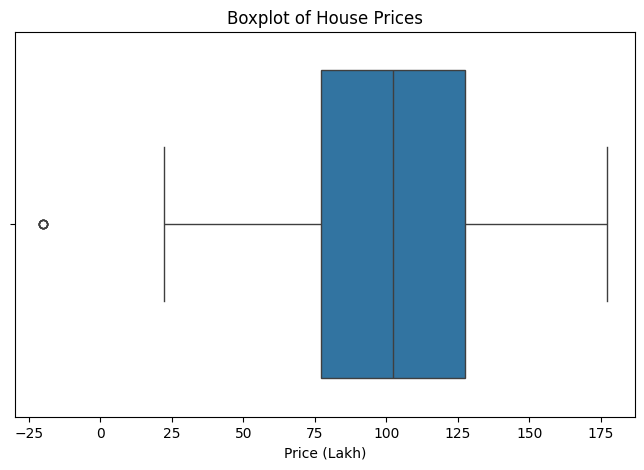

In [ ]:
# Outliers

plt.figure(figsize=(8, 5))

sns.boxplot(x=df["price_lakh"])

plt.title("Boxplot of House Prices")
plt.xlabel("Price (Lakh)")
plt.show()

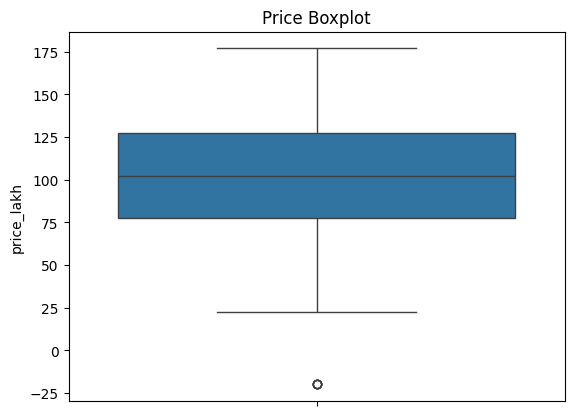

In [ ]:
sns.boxplot(y=df["price_lakh"])

plt.title("Price Boxplot")

plt.show()

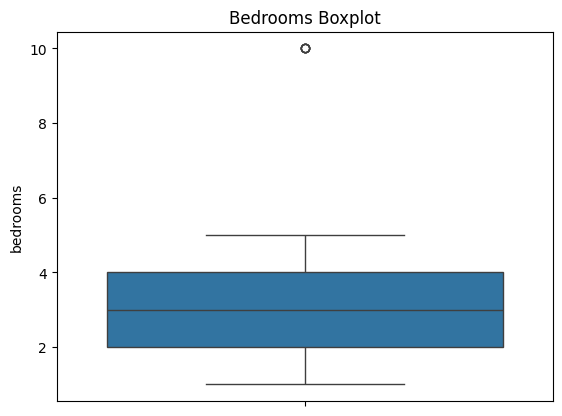

In [ ]:
sns.boxplot(y=df["bedrooms"])

plt.title("Bedrooms Boxplot")

plt.show()

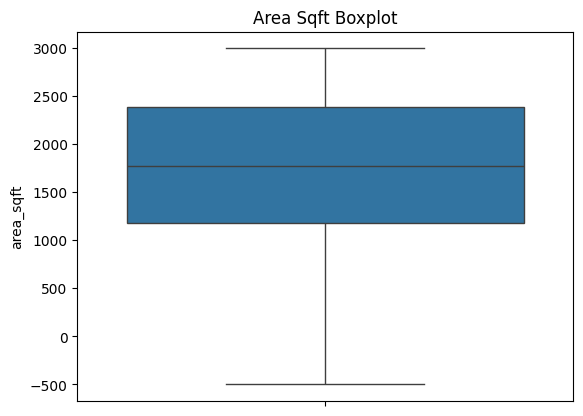

In [ ]:
sns.boxplot(y=df["area_sqft"])

plt.title("Area Sqft Boxplot")

plt.show()

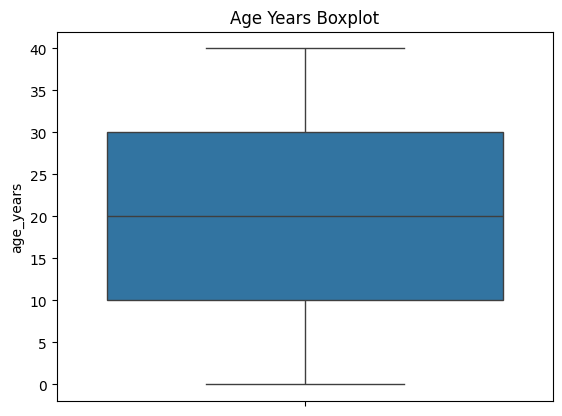

In [ ]:
sns.boxplot(y=df["age_years"])

plt.title("Age Years Boxplot")

plt.show()

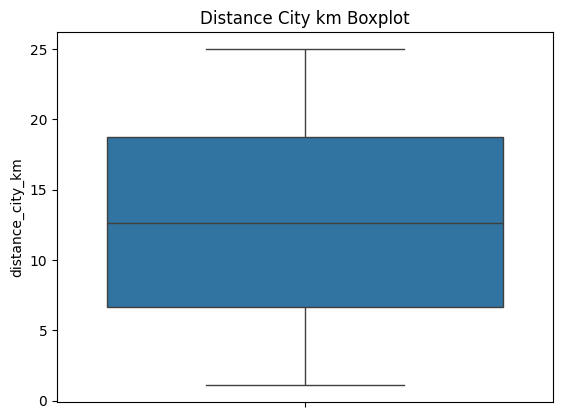

In [ ]:
sns.boxplot(y=df["distance_city_km"])

plt.title("Distance City km Boxplot")

plt.show()

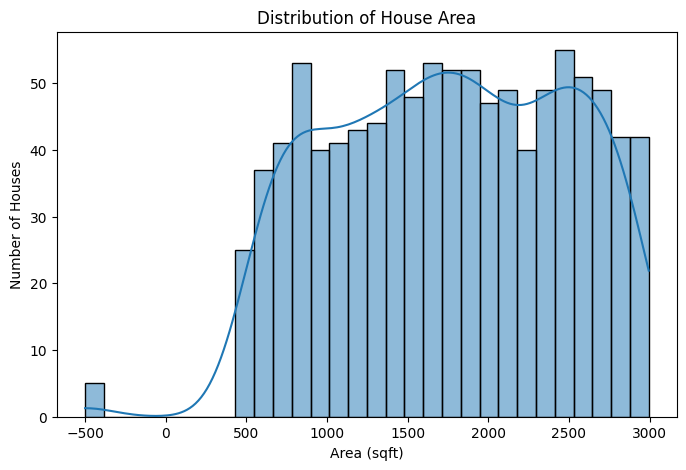

In [ ]:
# Plot Area Distribution
plt.figure(figsize=(8, 5))

sns.histplot(df["area_sqft"], bins=30, kde=True)

plt.title("Distribution of House Area")
plt.xlabel("Area (sqft)")
plt.ylabel("Number of Houses")

plt.show()

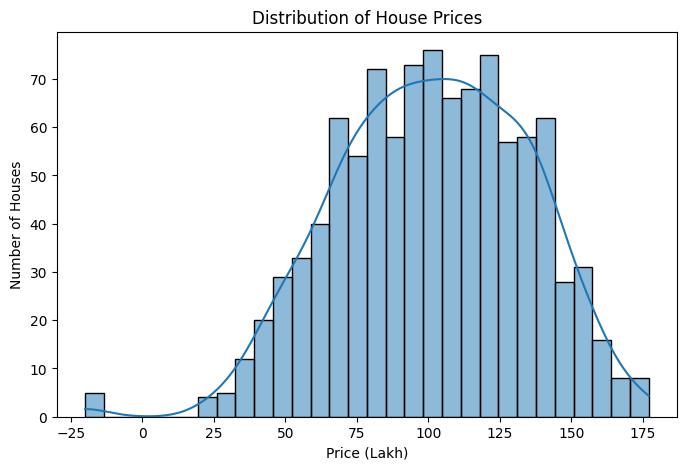

In [ ]:
# Price distribution
plt.figure(figsize=(8, 5))

sns.histplot(df["price_lakh"], bins=30, kde=True)

plt.title("Distribution of House Prices")
plt.xlabel("Price (Lakh)")
plt.ylabel("Number of Houses")

plt.show()

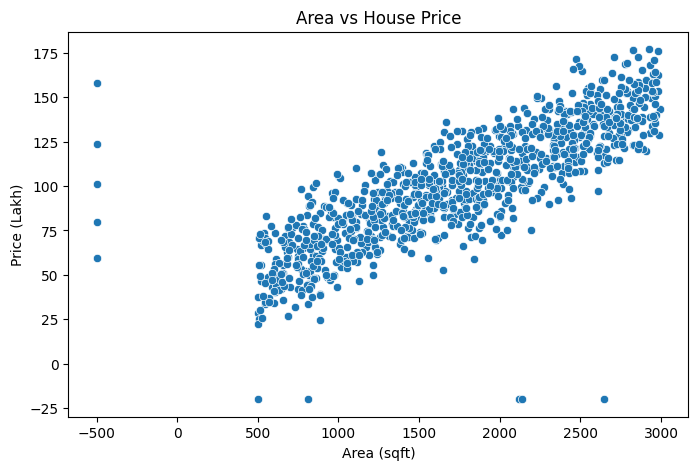

In [ ]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="area_sqft",
    y="price_lakh"
)

plt.title("Area vs House Price")
plt.xlabel("Area (sqft)")
plt.ylabel("Price (Lakh)")

plt.show()

In [ ]:
df["area_sqft"].corr(df["price_lakh"])

np.float64(0.8233073365702438)

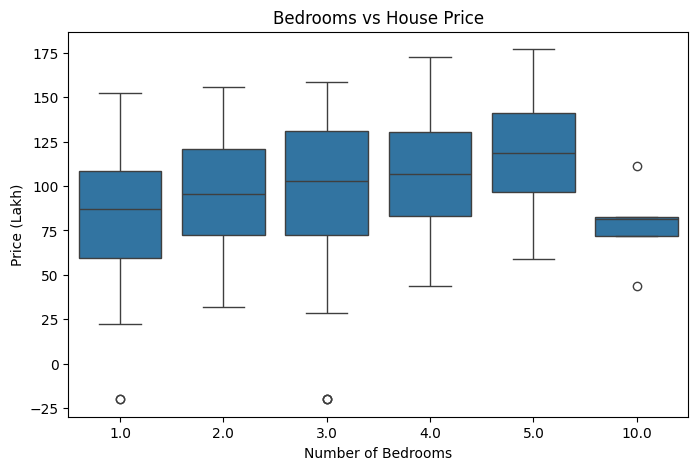

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="bedrooms",
    y="price_lakh"
)

plt.title("Bedrooms vs House Price")
plt.xlabel("Number of Bedrooms")
plt.ylabel("Price (Lakh)")

plt.show()

In [ ]:
df.groupby("bedrooms")["price_lakh"].mean()

,price_lakh
bedrooms,
1.0,85.115707
2.0,95.678325
3.0,100.590610
4.0,106.973460
5.0,118.116043
10.0,78.080000


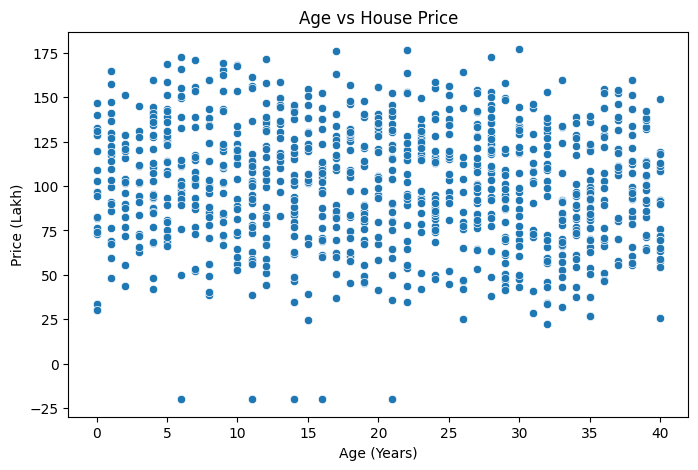

In [ ]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="age_years",
    y="price_lakh"
)

plt.title("Age vs House Price")
plt.xlabel("Age (Years)")
plt.ylabel("Price (Lakh)")

plt.show()

In [ ]:
df["age_years"].corr(df["price_lakh"])

np.float64(-0.11424399970929942)

In [ ]:
#correlations

print(df.corr(numeric_only=True))

                  area_sqft  bedrooms  age_years  distance_city_km  price_lakh
area_sqft          1.000000 -0.026421  -0.028633         -0.022666    0.823307
bedrooms          -0.026421  1.000000   0.002408          0.039448    0.285790
age_years         -0.028633  0.002408   1.000000          0.012030   -0.114244
distance_city_km  -0.022666  0.039448   0.012030          1.000000   -0.090868
price_lakh         0.823307  0.285790  -0.114244         -0.090868    1.000000


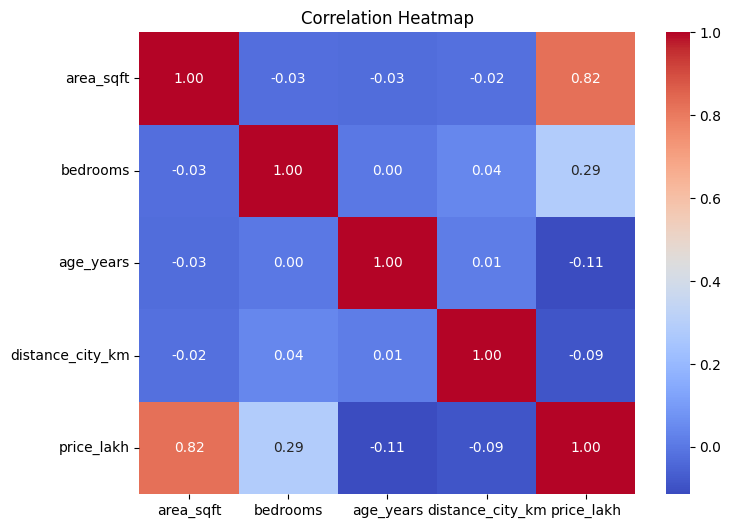

In [ ]:
#correlation heatmap

plt.figure(figsize=(8, 6))

correlation_matrix = df.corr(numeric_only=True)

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

**Data Cleaning**

In [ ]:
df_clean = df.copy()

In [ ]:
df_clean = df_clean.drop_duplicates()

print("Shape after removing duplicates:", df_clean.shape)

Shape after removing duplicates: (1000, 5)


In [ ]:
df_clean.loc[df_clean["area_sqft"] <= 0, "area_sqft"] = np.nan

df_clean.loc[
    (df_clean["bedrooms"] <= 0) | (df_clean["bedrooms"] > 10),
    "bedrooms"
] = np.nan

df_clean.loc[df_clean["age_years"] < 0, "age_years"] = np.nan

df_clean.loc[df_clean["distance_city_km"] < 0, "distance_city_km"] = np.nan

df_clean.loc[df_clean["price_lakh"] <= 0, "price_lakh"] = np.nan

In [ ]:
df_clean.isnull().sum()

,0
area_sqft,15
bedrooms,10
age_years,10
distance_city_km,10
price_lakh,5


In [ ]:
numeric_columns = [
    "area_sqft",
    "bedrooms",
    "age_years",
    "distance_city_km",
    "price_lakh"
]

for col in numeric_columns:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

In [ ]:
print(df_clean.isnull().sum())

area_sqft           0
bedrooms            0
age_years           0
distance_city_km    0
price_lakh          0
dtype: int64


In [ ]:
# Feature Engineering

df_clean["price_per_sqft"] = (
    df_clean["price_lakh"] * 100000
) / df_clean["area_sqft"]

In [ ]:
df_clean[[
    "area_sqft",
    "price_lakh",
    "price_per_sqft"
]].head()

,area_sqft,price_lakh,price_per_sqft
0,849.0,66.5,7832.744405
1,2068.0,120.2,5812.379110
2,1352.0,96.7,7152.366864
3,655.0,51.2,7816.793893
4,1062.0,58.4,5499.058380


In [ ]:
df_clean["area_per_bedroom"] = df_clean["area_sqft"] / df_clean["bedrooms"]

In [ ]:
df_clean[
    ["area_sqft", "bedrooms", "area_per_bedroom"]
].head()

,area_sqft,bedrooms,area_per_bedroom
0,849.0,5.0,169.800000
1,2068.0,4.0,517.000000
2,1352.0,3.0,450.666667
3,655.0,3.0,218.333333
4,1062.0,1.0,1062.000000


**Final Dataset Inspection**

In [ ]:
df_clean.head()

,area_sqft,bedrooms,age_years,distance_city_km,price_lakh,price_per_sqft,area_per_bedroom
0,849.0,5.0,33.0,17.6,66.5,7832.744405,169.800000
1,2068.0,4.0,18.0,1.6,120.2,5812.379110,517.000000
2,1352.0,3.0,30.0,9.6,96.7,7152.366864,450.666667
3,655.0,3.0,36.0,5.2,51.2,7816.793893,218.333333
4,1062.0,1.0,32.0,24.0,58.4,5499.058380,1062.000000


In [ ]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1000 entries, 0 to 1018
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   area_sqft         1000 non-null   float64
 1   bedrooms          1000 non-null   float64
 2   age_years         1000 non-null   float64
 3   distance_city_km  1000 non-null   float64
 4   price_lakh        1000 non-null   float64
 5   price_per_sqft    1000 non-null   float64
 6   area_per_bedroom  1000 non-null   float64
dtypes: float64(7)
memory usage: 62.5 KB


In [ ]:
df_clean.describe()

,area_sqft,bedrooms,age_years,distance_city_km,price_lakh,price_per_sqft,area_per_bedroom
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,1758.812000,3.041000,20.024000,12.791400,101.522000,6206.054298,786.601600
std,699.700334,1.459949,11.630765,6.900174,31.793481,1771.682730,618.725271
min,500.000000,1.000000,0.000000,1.100000,22.400000,2747.747748,61.300000
25%,1190.750000,2.000000,10.000000,6.700000,77.600000,5093.444203,364.950000
50%,1770.000000,3.000000,20.000000,12.700000,102.100000,5784.176690,584.733333
75%,2369.250000,4.000000,30.000000,18.700000,127.200000,6809.636099,952.833333
max,2995.000000,10.000000,40.000000,25.000000,177.000000,20257.936508,2970.000000


In [ ]:
df_clean.isnull().sum()

,0
area_sqft,0
bedrooms,0
age_years,0
distance_city_km,0
price_lakh,0
price_per_sqft,0
area_per_bedroom,0


In [ ]:
features = [
    "area_sqft",
    "bedrooms",
    "age_years",
    "distance_city_km",
    "area_per_bedroom"
]

X = df_clean[features]

y = df_clean["price_lakh"]

In [ ]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1000, 5)
y shape: (1000,)


In [ ]:
print("X columns:")
print(X.columns.tolist())

print("\ny:")
print(y.head())

X columns:
['area_sqft', 'bedrooms', 'age_years', 'distance_city_km', 'area_per_bedroom']

y:
0     66.5
1    120.2
2     96.7
3     51.2
4     58.4
Name: price_lakh, dtype: float64


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (800, 5)
Testing Data: (200, 5)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
X_train_scaled

array([[-1.78323651,  1.31371696, -1.30468002,  1.25853554, -1.10483756],
       [ 0.10773255, -1.38801458,  1.70248499,  0.4440671 ,  1.70030972],
       [-1.7717674 , -1.38801458,  0.67145699,  0.93856579, -0.41833764],
       ...,
       [-0.08294136, -0.71258169, -0.87508502,  1.53487304,  0.10607202],
       [-0.4986965 , -0.71258169,  0.32778099, -1.69391255, -0.12825587],
       [ 0.82025084, -0.71258169, -0.18773302, -1.21395793,  0.61512917]])

In [ ]:
X_test_scaled

array([[-1.13093103, -0.71258169,  0.58553799,  0.35680262, -0.48459587],
       [ 0.82025084,  0.63828408, -0.70324702,  1.1421829 , -0.32905063],
       [ 1.56574281, -1.38801458, -0.70324702,  1.34580001,  3.34383708],
       [-1.23988755,  0.63828408, -1.30468002,  0.38589078, -0.90961819],
       [ 0.40879662, -0.03714881, -1.21876102,  0.3713467 , -0.16892657],
       [-0.50443105,  0.63828408, -1.21876102, -0.66128292, -0.70235921],
       [ 0.53639043, -0.71258169, -0.01589502, -1.37394281,  0.45513978],
       [ 1.52846821,  0.63828408, -1.64835602,  0.40043486, -0.12946791],
       [-0.09010955, -1.38801458, -1.47651802,  1.4912408 ,  1.47729421],
       [-0.50156377, -0.71258169,  0.84329499, -0.03588752, -0.12987193],
       [-1.74882919, -0.03714881, -0.18773302, -0.41403358, -0.97964721],
       [ 0.24822911, -1.38801458,  0.07002399,  1.44760857,  1.85868305],
       [ 0.75143619, -0.71258169, -1.64835602, -0.71945924,  0.57634386],
       [-1.24992302, -0.71258169, -0.4

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train_scaled, y_train)

LinearRegression()

In [ ]:
y_pred = model.predict(X_test_scaled)
y_pred

array([ 62.54821631, 131.34428604, 125.4827928 ,  77.12581203,
       117.66781807,  99.94597764, 114.05331935, 156.45575668,
        86.21026358,  79.63192111,  55.53884797,  89.21005868,
       124.36230449,  66.43793929, 108.00194215,  70.58426194,
       114.66961431,  81.9601845 ,  83.66221206, 142.68102112,
        77.03553476,  95.59291915, 131.50774397, 148.37925114,
       107.14935724,  59.09937406,  71.09496438,  62.85914118,
       142.53024514,  95.02340145,  46.7275155 , 139.34425846,
        96.77064681,  71.51600581, 101.23309826, 128.77096586,
        80.05550047, 113.77857873, 131.62704962,  69.69080748,
       126.70414662,  77.46744368,  55.02349618, 138.5815845 ,
       118.73935915, 102.14769835,  94.18210394,  43.72386165,
        50.09898852,  55.17742232, 154.48856394, 115.41886147,
       150.71693974,  33.6200667 , 122.63742565,  72.49705004,
        66.88333821, 128.34405561, 133.55248147,  95.36653773,
       141.12867238, 153.15503769,  74.47724767,  92.26

In [ ]:
comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

print(comparison.head(10))

     Actual   Predicted
530    76.2   62.548216
751   122.4  131.344286
754   121.0  125.482793
672    75.5   77.125812
415   103.0  117.667818
691   100.2   99.945978
637   103.7  114.053319
521   157.7  156.455757
875    90.9   86.210264
136    82.9   79.631921


**Metrics**

In [ ]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred)
print("Mean Absolute Error:", mae)

Mean Absolute Error: 9.514479833857214


In [ ]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)

Mean Squared Error: 151.69403283288034


In [ ]:
rmse = np.sqrt(mse)
print("Root Mean Squared Error:", rmse)

Root Mean Squared Error: 12.316413148026513


In [ ]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)
print("R-squared:", r2)

R-squared: 0.8671977686420778


In [ ]:
n = X_test.shape[0]
p = X_test.shape[1]

adjusted_r2 = 1 - ((1 - r2) * (n - 1) / (n - p - 1))
print("Adjusted R-squared:", adjusted_r2)

Adjusted R-squared: 0.8637750307204819


In [ ]:
print("MAE:", mae)

print("MSE:", mse)

print("RMSE:", rmse)

print("R2:", r2)

print("Adjusted R2:", adjusted_r2)

MAE: 9.514479833857214
MSE: 151.69403283288034
RMSE: 12.316413148026513
R2: 0.8671977686420778
Adjusted R2: 0.8637750307204819


In [ ]:
area = float(input("Enter area (sqft): "))
bedrooms = int(input("Enter number of bedrooms: "))
age = float(input("Enter house age (years): "))
distance = float(input("Enter distance from city (km): "))

Enter area (sqft): 500
Enter number of bedrooms: 3
Enter house age (years): 5
Enter distance from city (km): 8


In [ ]:
input_data = pd.DataFrame({
    "area_sqft": [area],
    "bedrooms": [bedrooms],
    "age_years": [age],
    "distance_city_km": [distance]
})

# Create the same feature used during training
input_data["area_per_bedroom"] = (
    input_data["area_sqft"] / input_data["bedrooms"]
)

In [ ]:
# Apply the already-fitted preprocessing
input_processed = scaler.transform(input_data)

In [ ]:
# Predict
prediction = model.predict(input_processed)

print(f"\nPredicted House Price: ₹{prediction[0]:.2f} lakh")


Predicted House Price: ₹58.50 lakh
